In [8]:
import numpy as np
import matplotlib.pyplot as plt
import pybamm
import sys
sys.path.append('..')  # or sys.path.insert(0, '..')
import plot_settings
plot_settings.apply()
import sim_PyBaMM

In [9]:
# Polynomial function for OC voltage vs SOC (example coefficients)
def V_soc_poly(soc, coeffs):
    p = np.poly1d(coeffs)
    # return np.polyval(coeffs, soc)
    return p(soc)

def step(state, I, p, coeffs):
    soc, U1 = state

    # Voltage at current state
    V_soc = V_soc_poly(soc, coeffs)
    V = V_soc - I*p['R0'] - U1

    # Evolve state
    soc_new = soc - (I * p['dt'] / p['Q'])
    U1_new = p['a']*U1 + p['R1']*(1 - p['a'])*I
    
    return (soc_new, U1_new), V, V_soc

def simulation(p, coeffs):
    # initial state
    state = (1.0, 0.0)
    soc = state[0]
    U1 = state[1]
    
    time = []
    I_list = []
    soc_list = []
    U1_list = []
    V_list = []
    V_soc_list = []
    
    t = 0
    while soc > 0:
        I = current_profile(t, p)
        time.append(t)
        I_list.append(I)
        soc_list.append(soc)
        U1_list.append(U1)
        
        # Calculate voltage at current state
        V_soc = V_soc_poly(soc, coeffs)
        V = V_soc - I*p['R0'] - U1
        V_list.append(V)
        V_soc_list.append(V_soc)

        # Update state
        state, _, _ = step(state, I, p, coeffs)
        soc, U1 = state

        t += p['dt']

    return time, I_list, soc_list, U1_list, V_list, V_soc_list

In [10]:
def simulate_pybamm(I0, p):
    model = pybamm.lithium_ion.SPM()
    param = model.default_parameter_values
    def my_current(t, I0=I0):
        return current_profile_pybamm(t)
    
    param["Current function [A]"] = my_current

    param.process_model(model)
    geometry = model.default_geometry
    param.process_geometry(geometry)
    mesh = pybamm.Mesh(geometry, model.default_submesh_types, model.default_var_pts)
    disc = pybamm.Discretisation(mesh, model.default_spatial_methods)
    disc.process_model(model)
    t_eval = [0,3*3600]

    solver = pybamm.IDAKLUSolver(atol=1e-6, rtol=1e-3)
    solution = solver.solve(model, t_eval)

    npc_v = solution.observe(model.variables['Voltage [V]'])
    npc = solution.observe(model.variables['Battery open-circuit voltage [V]'])
    npc_soc = solution.observe(model.variables['Average negative particle concentration'])
    npc_I = solution.observe(model.variables['Current variable [A]'])
    return solution,model, npc_v, npc, npc_soc, npc_I

def fit_func(solution, npc):
    t_ = np.linspace(0,solution['Time [s]'].entries[-1],101)
    coeffs_ = np.polyfit(np.linspace(1,0,101), npc(t_), 6)
    poly = np.poly1d(coeffs_)  # Create polynomial function
    return poly, coeffs_, t_


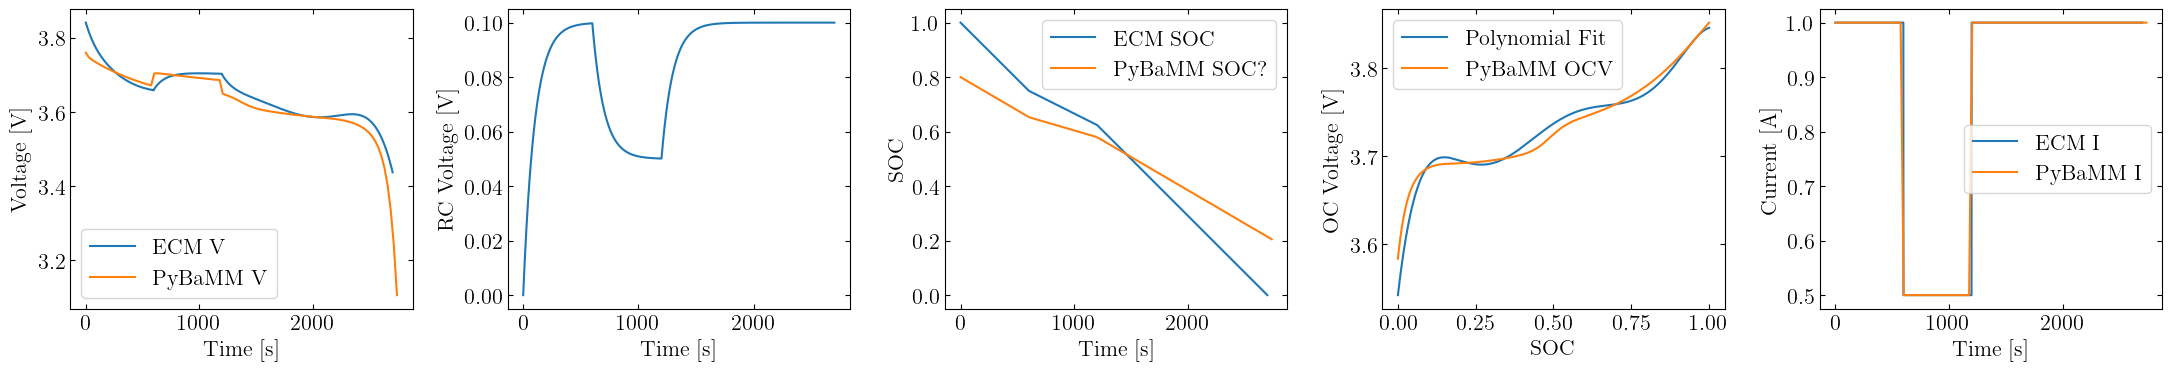

In [14]:
# Parameters
params = dict(
    R0=0.005, # Ohm
    R1=0.1, # Ohm
    C1=1000, # F
    dt=1, # time step in seconds
    I0=1. # Current in A
)
params['Q'] = 2400 # Capacity in As (1Ah = 3600 As)
# params['Q'] = params['I0'] * params['t_tot'] # Capacity in As (1Ah = 3600 As)
params['a'] = np.exp(-params['dt'] / (params['R1'] * params['C1'])) # Time constant for the RC circuit


def current_profile(t, p):
    if t < 600:
        return p['I0']
    elif t < 1200:
        return 0.5
    else:
        return 1


def current_profile_pybamm(t):

    times = np.array([0, 600, 600, 1200, 1200, 1300])
    values = np.array([1, 1, 0.5, 0.5, 1, 1])

    I = pybamm.Interpolant(times, values, pybamm.t)
    return I

# PyBaMM
solution, model, npc_v, npc, npc_soc, npc_I = simulate_pybamm(I0=params['I0'], p=params)
poly, coeffs_, t_ = fit_func(solution, npc)

# ECM
time, I, soc, U1, V, V_soc = simulation(p=params, coeffs=coeffs_)

# Plotting
fig, (ax1, ax2, ax3, ax4, ax5) = plt.subplots(1, 5, figsize=(22, 4))
ax1.plot(time, V, label='ECM V')
ax1.plot(t_, npc_v(t_), label='PyBaMM V')
ax1.legend()
ax1.set_ylabel('Voltage [V]')
ax1.set_xlabel('Time [s]')
ax2.plot(time, U1, label='RC Voltage [V]')
ax2.set_ylabel('RC Voltage [V]')
ax2.set_xlabel('Time [s]')
ax3.plot(time, soc, label='ECM SOC')
ax3.plot(t_, npc_soc(t_), label='PyBaMM SOC?')
ax3.legend()
ax3.set_ylabel('SOC')
ax3.set_xlabel('Time [s]')
ax4.plot(soc, poly(soc), label='Polynomial Fit')
ax4.plot(soc, npc(time), label='PyBaMM OCV')
ax4.set_xlabel('SOC')
ax4.set_ylabel('OC Voltage [V]')
ax4.legend()
ax5.plot(time, I, label='ECM I')
ax5.plot(t_, npc_I(t_), label='PyBaMM I')
ax5.legend()
ax5.set_xlabel('Time [s]')
ax5.set_ylabel('Current [A]')
plt.tight_layout()

# print(soc, npc(time).shape)